In [1]:
import zipfile
from google.colab import drive

drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
zip_ref = zipfile.ZipFile("/content/drive/MyDrive/PhD AI/Stomata Project/stomata_images/dataset_intero.zip", 'r')
zip_ref.extractall("/content/tmp")
zip_ref.close()

In [3]:
import numpy as np
import pandas as pd
from skimage import io
from skimage import transform
from skimage.feature import structure_tensor
from skimage.transform import rotate
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from scipy import stats as st


In [4]:
# Computes moving average of signal x with 'same' padding
# using a rolling window of length w
def moving_average(x, w):
  return np.convolve(x, np.ones(w), 'same') / w


# Get lengths of 1s and 0s patches
def get_signal_lengths(signal):
  interval_length_ones = []
  interval_length_zeros = []
  section_lengths = []
  count_ones = 0
  count_zeros = 0

  for i in range(len(signal)):
    if signal[i] == 1:
      count_ones += 1
      count_zeros = 0  # Reset zero count when encountering a one
    elif signal[i] == 0:
      count_zeros += 1
      count_ones = 0  # Reset one count when encountering a zero
    # Append counts when signal changes
    if count_ones > 0 and (i == len(signal) - 1 or signal[i+1] == 0):
      interval_length_ones.append(count_ones)
      section_lengths.append(count_ones)
      count_ones = 0
    if count_zeros > 0 and (i == len(signal) - 1 or signal[i+1] == 1):
      interval_length_zeros.append(count_zeros)
      section_lengths.append(-count_zeros)
      count_zeros = 0
  # Return results
  return np.array(interval_length_zeros), np.array(interval_length_ones), np.array(section_lengths)


def adaptive_gamma_correction(im, mask=None, target_mean=0.4):
    """
    im: immagine in [0,1]
    mask: booleana per escludere i pixel (es. black_pixels)
    target_mean: a che media vogliamo portare l'immagine dopo la correzione
    """
    if mask is None:
        vals = im.ravel()
    else:
        vals = im[~mask]

    # 1) stretch contrast
    p2, p98 = np.percentile(vals, (2, 98))
    eps = 1e-6
    im_stretched = np.clip((im - p2) / (p98 - p2 + eps), 0, 1)

    # 2) gamma selection
    vals_stretched = im_stretched[~mask] if mask is not None else im_stretched.ravel()
    mean_int = np.clip(vals_stretched.mean(), eps, 1 - eps)
    gamma = np.log(target_mean) / np.log(mean_int)   # mean_int^gamma ≈ target_mean

    im_gamma = np.power(im_stretched, gamma)
    return im_gamma


def get_veins_lengths(filename, image_area=2.39, convert_to_mm=False, show_result=False):
  """
  Params
    - filename: the filename of the image
    - image_area: the real area in mm^2 of the photo
    - convert_to_mm: if True, the lengths will be converted to mm
    - show_result: if True, plot of the image with identified veins and
                    intervals will be shown
  Returns
    - veins_lengths: the lengths of the veins in mm (VEINS)
    - veins_intervals: the intervals between veins in px/mm
    - all_lengths: the lengths of the veins (NEGATIVES) and intervals (POSITIVES) in px/mm
  """
  # Import image
  im = io.imread(filename, as_gray=True)
  # Divide the image in patches and compute the structure_tensor
  # i.e. the derivative of the image signal (find direction of edges)
  Axx, Axy, Ayy = structure_tensor(im, sigma=20)
  orientations = 0.5 * np.arctan2(2 * Axy, Axx - Ayy)
  # Take the median to find the dominant angle
  dominant_angle = np.rad2deg(np.median(orientations))
  #print(dominant_angle)
  # Use the dominant angle to rotate the image
  # Obtain horizontal veins and resize image to maintain dimensions
  # Constant padding (pixels outside the photo are set to black)
  adjusted_im = rotate(im, -dominant_angle, resize=True)

  # Boolean vector of black pixels later used to
  # avoid black_pixels in mean computation
  black_pixels = (adjusted_im==0)

    # --- NUOVA PARTE: gamma correction adattiva + binarizzazione ---
  adjusted_im = adaptive_gamma_correction(adjusted_im, mask=black_pixels,
                                          target_mean=0.4)

  # soglia automatica (Otsu) sui soli pixel non-neri
  thresh = threshold_otsu(adjusted_im[~black_pixels])
  adjusted_im = (adjusted_im >= thresh).astype(np.int64)
  # ---------------------------------------------------------------

  # Gamma correction to highlith veins
  # adjusted_im = np.int64(np.clip(np.pow(adjusted_im,20)+0.999999995,0,1))

  # Obtain the signal of veins (peaks are intervals between veins)
  signal = np.mean(adjusted_im, axis=1, where=~black_pixels)
  # Smooth signal
  signal = moving_average(signal, 15)
  # Threshold and flatten the signal
  signal = np.clip(signal>np.mean(signal),0,1)
  # Get lengths
  veins_lengths, veins_intervals, all_lengths = get_signal_lengths(signal)
  # Remove outliers (partial veins or intervals at the edges of the image)
  # veins_lengths = veins_lengths[veins_lengths >= np.percentile(veins_lengths, 0)]
  # veins_intervals = veins_intervals[veins_intervals >= np.percentile(veins_intervals, 0)]
  # From pixels to millimeters
  if convert_to_mm:
    veins_lengths = veins_lengths * image_area / adjusted_im.shape[1]
    veins_intervals = veins_intervals * image_area / adjusted_im.shape[1]
    all_lengths = all_lengths * image_area / adjusted_im.shape[1]
  # Show plot result
  if show_result:
    image_width = adjusted_im.shape[1]
    image_height = adjusted_im.shape[0]
    plt.imshow(adjusted_im,cmap="gray")
    plt.scatter(x=signal*(image_width//10)+(image_width//2-image_width//10),
                y=list(range(0,image_height)),
                c='r', marker=".")
    plt.show()
  # Return results
  return veins_lengths, veins_intervals, all_lengths, dominant_angle

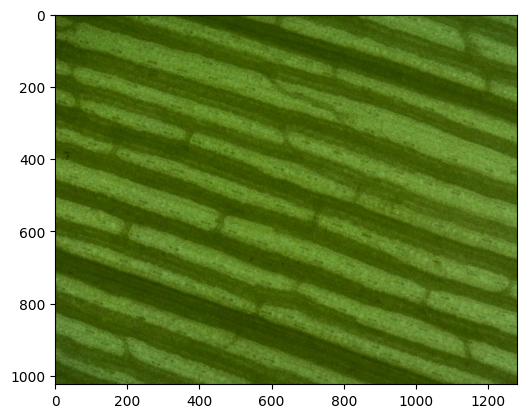

In [9]:
plt.imshow(io.imread("/content/tmp/dataset_intero/108.1.3.5.b.1.jpg"))

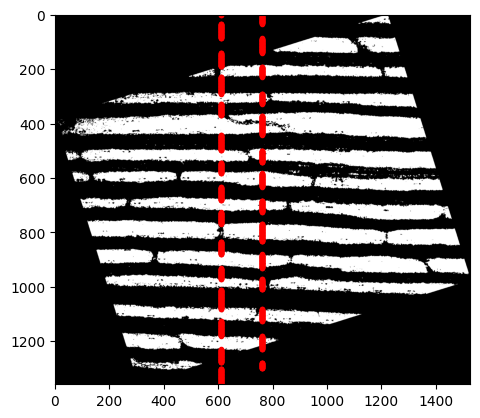

(array([ 2, 54, 51, 63, 43, 57, 39, 50, 43, 47, 40, 71, 55, 49, 58]),
 array([31, 53, 37, 37, 71, 45, 50, 43, 65, 51, 39, 44, 49, 22]),
 array([ -2,  31, -54,  53, -51,  37, -63,  37, -43,  71, -57,  45, -39,
         50, -50,  43, -43,  65, -47,  51, -40,  39, -71,  44, -55,  49,
        -49,  22, -58]),
 np.float64(-17.365256277146297))

In [10]:
get_veins_lengths("/content/tmp/dataset_intero/108.1.3.5.b.1.jpg", show_result=True)

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# Parse filename
def parse_filename(filename):
    try:
        parts = filename.split('.')
        treat_code = parts[0]
        batch = parts[1]
        block = parts[2]
        plant_number = parts[3]
        top_bottom = parts[4]
        image_replicate = parts[5].split('.')[0] # Handle .jpg extension
        return treat_code, batch, block, plant_number, top_bottom, image_replicate
    except (IndexError, ValueError):
        print(f"Warning: Could not parse filename {filename}. Skipping.")
        return None

# Process images and extract data
def process_images_and_create_csv(output_csv_path):

    data = []
    root_dir = "/content/tmp"

    # Walk through folders
    for root, dirs, files in os.walk(root_dir):
        # Create a progress bar for files in THIS folder
        for file in tqdm(files, desc=f"Processing files in {root}", unit="file"):
            filepath = os.path.join(root, file)
            if 'Thumbnail' not in root:  # Ignore Thumbnail folders
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    filepath = os.path.join(root, file)
                    # Remove extension before parsing
                    parsed_data = parse_filename(file[:-4])
                    if parsed_data:
                        treat_code, batch, block, plant_number, top_bottom, image_replicate = parsed_data

                        try:
                            vein_lengths, interval_lengths, all_lengths, dominant_angle = get_veins_lengths(filepath)
                            data.append([file, treat_code, batch, block, plant_number, top_bottom, image_replicate, vein_lengths, interval_lengths, all_lengths, dominant_angle])
                            #print(f"Processed {filepath}")
                        except Exception as e:
                            print(f"\nError processing {filepath}: {e}")
                            data.append([file, None, None, None, None, None, None, None, None, None, None])

        # Create DataFrame
        df = pd.DataFrame(data, columns=['filename', 'treat_code', 'batch', 'block', 'plant_number', 'top/bottom', 'image_replicate', 'vein_lengths', 'interval_lengths', 'all_lengths', 'dominant_angle'])
        df.to_csv(output_csv_path, index=False)

In [ ]:
# Example usage
output_csv_path = "/content/drive/MyDrive/PhD AI/Stomata Project/stomata_df_251212.csv"
process_images_and_create_csv(output_csv_path)